# Advanced Architectural Guide to Matplotlib
### A Pedagogical Framework for Data Visualization and Object-Oriented Plotting

**Target Audience:** Advanced Undergraduate and Graduate Students in Quantitative Disciplines.  
**Language Paradigm:** Academic English.  
**Objective:** To transition from heuristic plotting to a rigorous mastery of Matplotlib's Object-Oriented (OO) API, enabling precise control over multi-dimensional data representations and typographic quality.

## 1. The Core Paradigm: State-Based vs. Object-Oriented API

Matplotlib offers two distinct interfaces:
1. **`pyplot` (State-Based):** Inherited from MATLAB, it relies on a hidden global state machine. While convenient for rapid prototyping, it becomes intractable for complex, multi-figure visualizations.
2. **Object-Oriented (OO) API:** The rigorous standard for production and academic environments. You explicitly instantiate and manipulate `Figure` (the blank canvas) and `Axes` (the coordinate systems attached to the canvas) objects.

Let us examine the foundational anatomy of an OO visualization, plotting a continuous function.

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ql/x6w2nzxj32587rwzct46pnqh0000gn/T/ipykernel_82186/67219756.py:17: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Standard Deviations ($\sigma$)', fontsize=12)


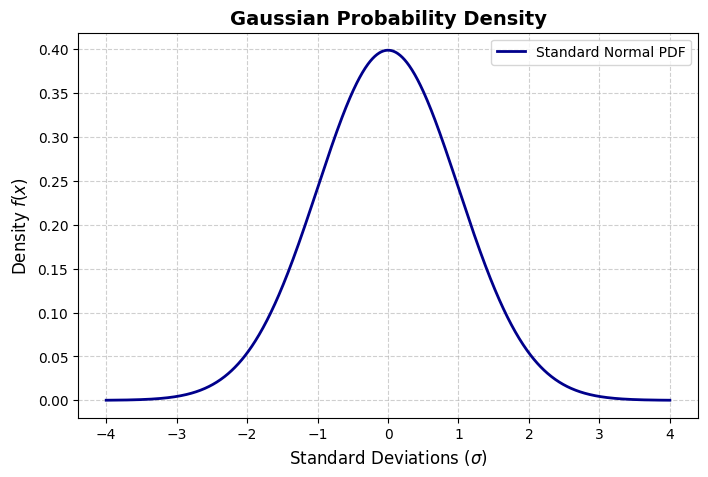

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the mathematical space
x = np.linspace(-4, 4, 1000)
y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

# 2. Instantiate the Figure and Axes objects
# figsize specifies the dimensions in inches
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Execute methods on the Axes object
ax.plot(x, y, color='darkblue', linewidth=2, label='Standard Normal PDF')

# 4. Apply structural formatting and LaTeX typography (using $...$)
ax.set_title('Gaussian Probability Density', fontsize=14, fontweight='bold')
ax.set_xlabel('Standard Deviations ($\sigma$)', fontsize=12)
ax.set_ylabel('Density $f(x)$', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')

# 5. Render the figure
plt.show()

## 2. Multi-Axes Dimensionality: The Grid System

In quantitative analysis, comparing concurrent metrics (e.g., multi-asset stochastic trajectories or comparative structural models) necessitates grid-based subplots. The `plt.subplots(nrows, ncols)` method returns an array of `Axes` objects, allowing programmatic iteration.

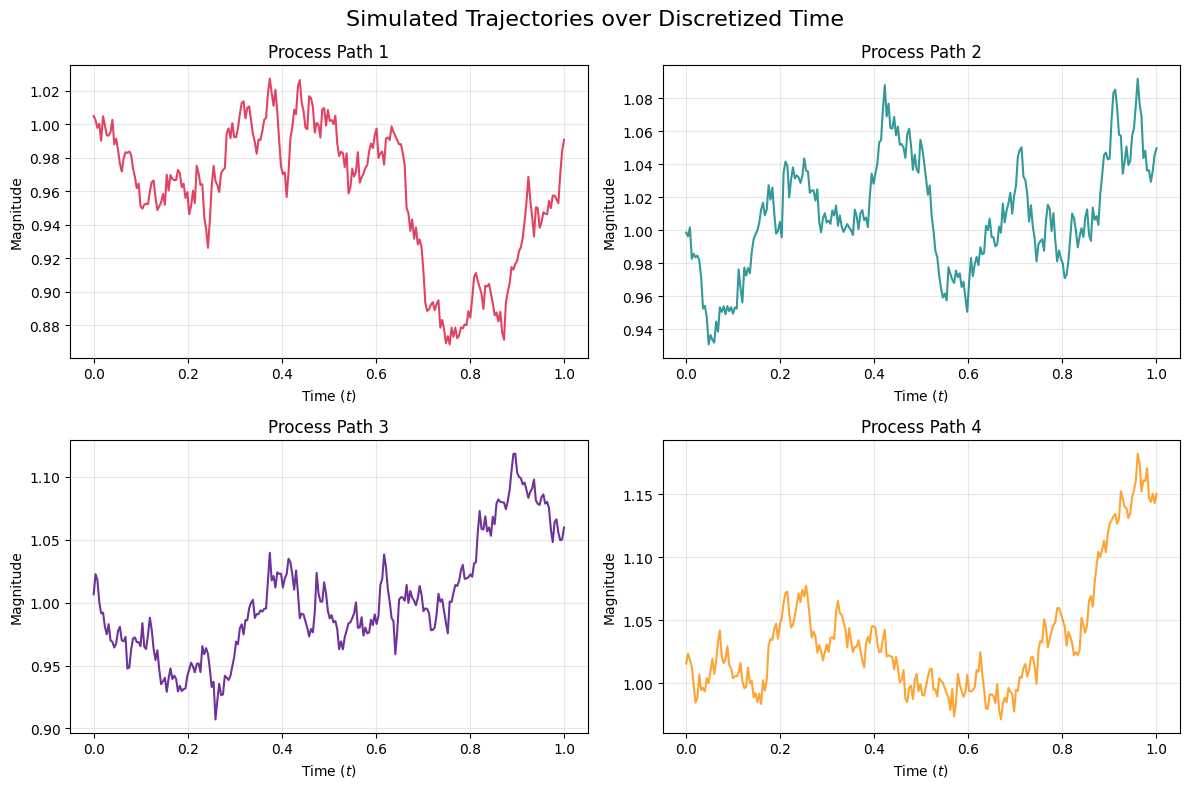

In [2]:
# Simulate four distinct stochastic paths
np.random.seed(42)
time_steps = np.linspace(0, 1, 252)
trajectories = np.exp(np.cumsum(np.random.normal(0, 0.01, (252, 4)), axis=0))

# Initialize a 2x2 grid. 'axes' is a 2D NumPy array of Axes objects
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Simulated Trajectories over Discretized Time', fontsize=16)

colors = ['crimson', 'teal', 'indigo', 'darkorange']

# Flatten the axes array for linear iteration
for i, ax in enumerate(axes.flatten()):
    ax.plot(time_steps, trajectories[:, i], color=colors[i], alpha=0.8)
    ax.set_title(f'Process Path {i+1}', fontsize=12)
    ax.set_xlabel('Time ($t$)')
    ax.set_ylabel('Magnitude')
    ax.grid(alpha=0.3)

# Optimize inter-plot spacing to prevent label collision
plt.tight_layout()
plt.show()

## 3. Topographical and Bivariate Visualization

Visualizing scalar fields defined over two variables, $f(x, y)$, requires projecting 3D structures into a 2D plane using color mapping. `contour` and `contourf` (filled contours) map mathematical matrices to visual gradients, essential for mapping topological surfaces.

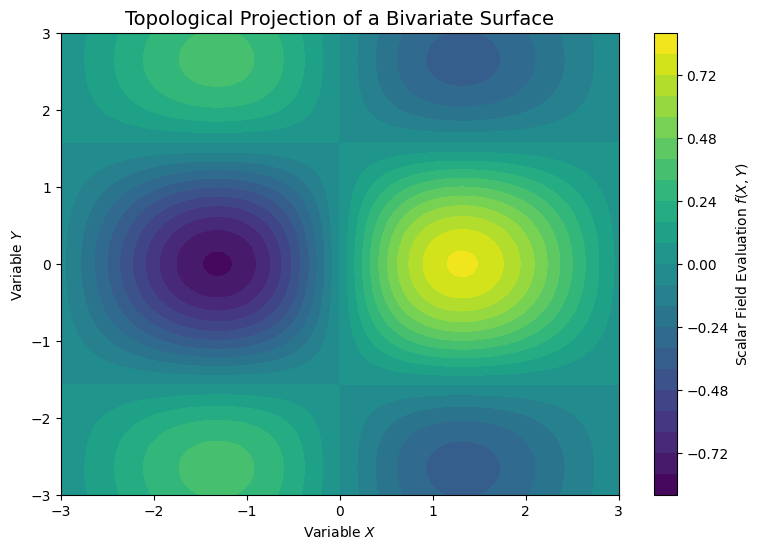

In [3]:
# Define a 2D Cartesian grid
x_domain = np.linspace(-3, 3, 100)
y_domain = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_domain, y_domain)

# Evaluate a non-linear bivariate function
Z = np.sin(X) * np.cos(Y) * np.exp(-(X**2 + Y**2) / 10)

fig, ax = plt.subplots(figsize=(9, 6))

# Generate filled contour intervals ('levels' defines resolution)
contour_map = ax.contourf(X, Y, Z, levels=25, cmap='viridis')

# Instantiate a Colorbar mapped to the specific contour object
cbar = fig.colorbar(contour_map, ax=ax)
cbar.set_label('Scalar Field Evaluation $f(X,Y)$')

ax.set_title('Topological Projection of a Bivariate Surface', fontsize=14)
ax.set_xlabel('Variable $X$')
ax.set_ylabel('Variable $Y$')

plt.show()

## 3. 3D plots

Visualizing scatters, surfaces or other plots projecting 3D structures.

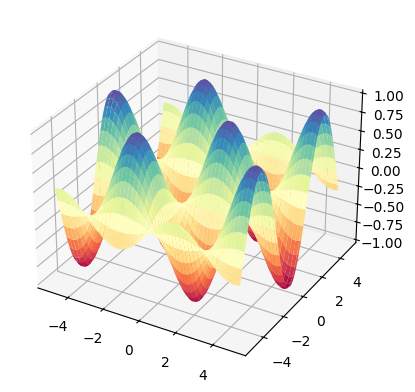

In [11]:
# Define a 2D Cartesian grid
x_domain = np.linspace(-5, 5, 100)
y_domain = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_domain, y_domain)
Z = np.sin(X) * np.cos(Y)

ax = plt.axes(projection="3d")
ax.plot_surface(X,Y,Z,cmap="Spectral")
plt.show()

## Conclusion and Empirical Best Practices
To maintain academic rigor in visual representations:
1. **Never conflate the APIs:** Systematically utilize `fig, ax = plt.subplots()` instead of global `plt.*` calls.
2. **Typography Matters:** Leverage LaTeX strings (e.g., `r'$\alpha$'`) for mathematical nomenclature in labels and legends.
3. **Color Theory:** Utilize perceptually uniform colormaps (like `viridis` or `cividis`) that remain interpretable in grayscale prints and are accessible.